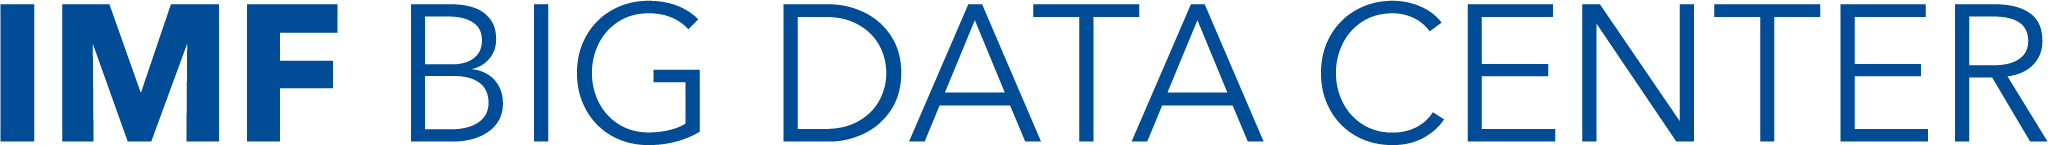

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/imfgit/imf_big_data_workshop_sti26/blob/main/notebooks/BDC_NLP_Fundamentals.ipynb)

# NLP Fundamentals


---

<br>**Contributors:** [Alberto Sanchez](asanchez3@imf.org)
<br> **Last update:** 2025-09-30 (Created: 2025-September)
<br> **Description:** Overview of the basic elements of Natural Language Processing through a sentence matching problem. This notebook is organized into three main sections: (1) dataset overview and text handling, (2) application of text similarity methods from edit distance to embeddings, and (3) an assessment of the different results and discussion questions.
<br> **References:**

https://srdas.github.io/NLPBook/IntroTextAnalytics.html

https://www.geeksforgeeks.org/nlp/natural-language-processing-nlp-tutorial/


## Dataset overview and text handling

<h3> <b> Problem statement: Sentence similarity </b>

Match IMF and World Bank topics using their text descriptors

### Set up

Import libraries and install necessary packages

In [38]:
# install required libraries. Will need to restart runtime
!pip install gensim # word2vec embeddings
!pip install sent2vec # sent2vec embeddings

In [1]:
import os
import re
import time
import random
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import PlaintextCorpusReader

Mount Google Drive

In [2]:
#If using Google Colab
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Read datasets

<h3> ⏰ Don't forget to adjust the path </h3>

In [3]:
ROOT = '/content/drive/MyDrive/STI 2026/' #if using colab

workspace = "Day 4 - Text Analytics/"
data_folder = "Data"
folder = os.path.join(ROOT, workspace, data_folder)
os.path.exists(folder)


True

In [4]:
filename1 = 'WB_taxonomy.csv'
filename2 = 'IMF_taxonomy.csv'

# Correct the filepath by joining the folder path with the filenames
filepath1 = os.path.join(folder, filename1)
filepath2 = os.path.join(folder, filename2)

wb_tax = pd.read_csv(filepath1, encoding='latin-1')
imf_tax = pd.read_csv(filepath2, encoding='latin-1')

In [5]:
#Take a peek at the data
display(imf_tax.count())
display(wb_tax.count())

,0
imfTopicID,116
topLabel,116
level2Label,107
level3Label,75
fullLabel,116
descLong,116
descShort,116


,0
wbTopicID,1169
topLabel,1169
altLabel,517
detLabel,517
fullLabel,1169


In [6]:
display(wb_tax.head())
display(imf_tax.head())

,wbTopicID,topLabel,altLabel,detLabel,fullLabel
0,WB398,Female and Youth Entrepreneurship,Gender and Entrepreneurship,Gender and Entrepreneurship; Women and Busines...,Female and Youth Entrepreneurship Gender and E...
1,WB400,Innovation-Driven Inclusive Growth,Inclusive Innovation,Inclusive Innovation,Innovation-Driven Inclusive Growth Inclusive I...
2,WB442,Inflation,NaN,NaN,Inflation
3,WB444,Monetary Policy,Monetary and Exchange Rate Policy,Monetary and Exchange Rate Policy,Monetary Policy Monetary and Exchange Rate Pol...
4,WB355,International Remittances,NaN,NaN,International Remittances


,imfTopicID,topLabel,level2Label,level3Label,fullLabel,descLong,descShort
0,DEM,Demographic and Social,NaN,NaN,Demographic and Social ;;,"Population demographics, social indicators, an...","Population, social, and labor market data."
1,J20,Demographic and Social,Labor markets,NaN,Demographic and Social ;Labor markets;,"The labor market, encompassing employment, une...","Employment, unemployment, labor force particip..."
2,J21,Demographic and Social,Labor markets,Labor force,Demographic and Social ;Labor markets;Labor force,The total number of people employed and unempl...,Employed and unemployed people willing to work.
3,J64,Demographic and Social,Labor markets,Unemployment,Demographic and Social ;Labor markets;Unemploy...,The number of people who are actively seeking ...,People actively seeking employment but unable ...
4,E24,Demographic and Social,Labor markets,Employment,Demographic and Social ;Labor markets;Employment,"The number of people currently employed, inclu...","Number of employed people (jobs, industries)."


Create sentences and keep their IDs, considering:

- fullLabel contains the concatenated labels.
- WBG fullLabel includes all available information.
- IMF taxonomy includes extra information: topic descriptions long and short.

In [7]:
sent_wb_named = dict(zip(wb_tax['wbTopicID'], wb_tax['fullLabel']))
display(list(sent_wb_named.items())[:5])
sent_imf_named = dict(zip(imf_tax['imfTopicID'], imf_tax['descShort']))
display(list(sent_imf_named.items())[:5])

[('WB398',
  'Female and Youth Entrepreneurship Gender and Entrepreneurship Gender and Entrepreneurship  Women and Business  Female and Youth Entrepreneurship  Female Entrepreneurship  Female and Youth (Women) Entrepreneurship'),
 ('WB400',
  'Innovation-Driven Inclusive Growth Inclusive Innovation Inclusive Innovation'),
 ('WB442', 'Inflation  '),
 ('WB444',
  'Monetary Policy Monetary and Exchange Rate Policy Monetary and Exchange Rate Policy'),
 ('WB355', 'International Remittances  ')]

[('DEM', 'Population, social, and labor market data.'),
 ('J20',
  'Employment, unemployment, labor force participation, wages, and related indicators.'),
 ('J21', 'Employed and unemployed people willing to work.'),
 ('J64', 'People actively seeking employment but unable to find it.'),
 ('E24', 'Number of employed people (jobs, industries).')]


<br>
<h3> <b>❓ Would you use a different column selection to create the final sentences?
</b>



Combine sentences into one single list

In [8]:
# stores IMF sentences in the negative IDs and WB in the positives IDs. Useful to differentiate later on between sentence groups
sent_combined_named = sent_wb_named.copy()
sent_combined_named.update(sent_imf_named)

# Display the first few items to verify
display(list(sent_combined_named.items())[:5])
display(list(sent_combined_named.items())[-5:])

[('WB398',
  'Female and Youth Entrepreneurship Gender and Entrepreneurship Gender and Entrepreneurship  Women and Business  Female and Youth Entrepreneurship  Female Entrepreneurship  Female and Youth (Women) Entrepreneurship'),
 ('WB400',
  'Innovation-Driven Inclusive Growth Inclusive Innovation Inclusive Innovation'),
 ('WB442', 'Inflation  '),
 ('WB444',
  'Monetary Policy Monetary and Exchange Rate Policy Monetary and Exchange Rate Policy'),
 ('WB355', 'International Remittances  ')]

[('C53', 'Economic forecasts.'),
 ('FAC', "IMF's financial accounts."),
 ('FAC_A', "IMF's financial operations."),
 ('FAC_B', "IMF reports on member countries' policies."),
 ('WP', 'Datasets for research papers.')]

### Text handling

Tokenization

In [9]:
nltk.download('punkt')
nltk.download('punkt_tab')
tokenized_sentences = {key: nltk.word_tokenize(str(value)) for key, value in sent_combined_named.items()}
display(list(tokenized_sentences.items())[:2])
display(list(tokenized_sentences.items())[-2:])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[('WB398',
  ['Female',
   'and',
   'Youth',
   'Entrepreneurship',
   'Gender',
   'and',
   'Entrepreneurship',
   'Gender',
   'and',
   'Entrepreneurship',
   'Women',
   'and',
   'Business',
   'Female',
   'and',
   'Youth',
   'Entrepreneurship',
   'Female',
   'Entrepreneurship',
   'Female',
   'and',
   'Youth',
   '(',
   'Women',
   ')',
   'Entrepreneurship']),
 ('WB400',
  ['Innovation-Driven',
   'Inclusive',
   'Growth',
   'Inclusive',
   'Innovation',
   'Inclusive',
   'Innovation'])]

[('FAC_B',
  ['IMF', 'reports', 'on', 'member', 'countries', "'", 'policies', '.']),
 ('WP', ['Datasets', 'for', 'research', 'papers', '.'])]

Remove non-word characters like semicolon, commas, etc.



In [10]:
# Remove non-word characters from each tokenized sentence
cleaned_tokenized_sentences = {key: [word for word in tokens if word.isalpha()] for key, tokens in tokenized_sentences.items()}

# Display the first few cleaned tokenized sentences
display(list(cleaned_tokenized_sentences.items())[:2])
display(list(cleaned_tokenized_sentences.items())[-2:])

[('WB398',
  ['Female',
   'and',
   'Youth',
   'Entrepreneurship',
   'Gender',
   'and',
   'Entrepreneurship',
   'Gender',
   'and',
   'Entrepreneurship',
   'Women',
   'and',
   'Business',
   'Female',
   'and',
   'Youth',
   'Entrepreneurship',
   'Female',
   'Entrepreneurship',
   'Female',
   'and',
   'Youth',
   'Women',
   'Entrepreneurship']),
 ('WB400',
  ['Inclusive',
   'Growth',
   'Inclusive',
   'Innovation',
   'Inclusive',
   'Innovation'])]

[('FAC_B', ['IMF', 'reports', 'on', 'member', 'countries', 'policies']),
 ('WP', ['Datasets', 'for', 'research', 'papers'])]

Remove stopwords

In [11]:
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from each cleaned tokenized sentence
filtered_sentences = {key: [word for word in tokens if word.lower() not in stop_words] for key, tokens in cleaned_tokenized_sentences.items()}

# Display the first few filtered sentences
display(list(filtered_sentences.items())[:2])
display(list(filtered_sentences.items())[-2:])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('WB398',
  ['Female',
   'Youth',
   'Entrepreneurship',
   'Gender',
   'Entrepreneurship',
   'Gender',
   'Entrepreneurship',
   'Women',
   'Business',
   'Female',
   'Youth',
   'Entrepreneurship',
   'Female',
   'Entrepreneurship',
   'Female',
   'Youth',
   'Women',
   'Entrepreneurship']),
 ('WB400',
  ['Inclusive',
   'Growth',
   'Inclusive',
   'Innovation',
   'Inclusive',
   'Innovation'])]

[('FAC_B', ['IMF', 'reports', 'member', 'countries', 'policies']),
 ('WP', ['Datasets', 'research', 'papers'])]

Lower case

In [12]:
# Convert all words to lowercase
lowercase_sentences = {key: [word.lower() for word in tokens] for key, tokens in filtered_sentences.items()}

# Display the first few lowercase sentences
display(list(lowercase_sentences.items())[:2])
display(list(lowercase_sentences.items())[-2:])

[('WB398',
  ['female',
   'youth',
   'entrepreneurship',
   'gender',
   'entrepreneurship',
   'gender',
   'entrepreneurship',
   'women',
   'business',
   'female',
   'youth',
   'entrepreneurship',
   'female',
   'entrepreneurship',
   'female',
   'youth',
   'women',
   'entrepreneurship']),
 ('WB400',
  ['inclusive',
   'growth',
   'inclusive',
   'innovation',
   'inclusive',
   'innovation'])]

[('FAC_B', ['imf', 'reports', 'member', 'countries', 'policies']),
 ('WP', ['datasets', 'research', 'papers'])]

<br>
<h3> <b>❓ Can you think of situations where we would keep stop words and original word case?
</b>

Remove duplicate words

In [13]:
# Remove duplicate words from each sentence
unique_word_sentences = {key: list(dict.fromkeys(tokens)) for key, tokens in lowercase_sentences.items()}

# Display the first few sentences with unique words
display(list(unique_word_sentences.items())[:2])
display(list(unique_word_sentences.items())[-2:])

[('WB398',
  ['female', 'youth', 'entrepreneurship', 'gender', 'women', 'business']),
 ('WB400', ['inclusive', 'growth', 'innovation'])]

[('FAC_B', ['imf', 'reports', 'member', 'countries', 'policies']),
 ('WP', ['datasets', 'research', 'papers'])]

<br>
<h3> <b>❓ Can you think of reasons why we would like to keep the duplicate words?
</b>

In [14]:
# reset back to filtered_sentences before attempting advanced text processing
filtered_sentences = unique_word_sentences

# NOTE: use a different variable depending on the processing attempted. For example, if you didn't remove duplicate words, you can reset to:
# filtered_sentences = lowercase_sentences

### Advanced text handling

Look at the context in which words appear. Feel free to try different words!

[Concordance](https://www.nltk.org/howto/concordance.html)

In [15]:
from nltk.text import Text

# Flatten the list of lists into a single list of words
all_filtered_words = [word for tokens in filtered_sentences.values() for word in tokens]

# Create an NLTK Text object
text = Text(all_filtered_words)

# Use the concordance method on the Text object
text.concordance('youth')

Displaying 5 of 5 matches:
                              female youth entrepreneurship gender women busine
on deracination urban crime violence youth violence sexual gbv gbsv social anal
e groups disability orphans children youth street children improving quality se
ernal health women adolescent health youth teenage young adult midwives traditi
s tourism hospitality inclusive jobs youth employment minorities disenfranchise


Context

In [16]:
text.similar('youth')

conflict


Common context

In [17]:
w1 = 'conflict'
w2 = 'youth'
print(text.similar(w1))
print(' ')
print(text.similar(w2))
print(' ')
text.common_contexts([w1,w2])

youth
None
 
conflict
None
 
violence_violence


Word frequencies

In [18]:
from nltk.probability import FreqDist

FreqDist(text).most_common(20)

[('management', 79),
 ('services', 49),
 ('financial', 48),
 ('law', 46),
 ('health', 46),
 ('education', 45),
 ('policy', 43),
 ('development', 39),
 ('systems', 36),
 ('public', 32),
 ('social', 30),
 ('trade', 28),
 ('climate', 27),
 ('information', 25),
 ('transport', 25),
 ('change', 25),
 ('employment', 25),
 ('water', 24),
 ('labor', 24),
 ('economic', 22)]

In [19]:
# Separate the filtered sentences by origin (WB or IMF)
wb_filtered_words = [word for key, tokens in filtered_sentences.items() if key in wb_tax['wbTopicID'].values for word in tokens]
imf_filtered_words = [word for key, tokens in filtered_sentences.items() if key in imf_tax['imfTopicID'].values for word in tokens]

# Calculate word frequencies for WB
wb_freq_dist = FreqDist(wb_filtered_words)
print("Top 20 most common words in WB sentences:")
display(wb_freq_dist.most_common(20))

# Calculate word frequencies for IMF
imf_freq_dist = FreqDist(imf_filtered_words)
print("\nTop 20 most common words in IMF sentences:")
display(imf_freq_dist.most_common(20))

Top 20 most common words in WB sentences:


[('management', 79),
 ('law', 46),
 ('education', 45),
 ('health', 44),
 ('policy', 42),
 ('services', 40),
 ('development', 39),
 ('systems', 36),
 ('public', 32),
 ('social', 27),
 ('financial', 25),
 ('trade', 25),
 ('information', 25),
 ('transport', 25),
 ('water', 24),
 ('employment', 23),
 ('technologies', 22),
 ('labor', 22),
 ('growth', 21),
 ('regulation', 21)]


Top 20 most common words in IMF sentences:


[('financial', 23),
 ('assets', 11),
 ('change', 10),
 ('economic', 9),
 ('prices', 9),
 ('services', 9),
 ('climate', 8),
 ('risks', 8),
 ('goods', 8),
 ('country', 8),
 ('rates', 7),
 ('institutions', 7),
 ('bank', 7),
 ('average', 6),
 ('people', 5),
 ('countries', 5),
 ('liabilities', 5),
 ('money', 5),
 ('government', 5),
 ('activities', 5)]

Bigrams

In [20]:
from nltk.util import bigrams

bigrams_list = list(bigrams(text))
display(bigrams_list[:10])

[('female', 'youth'),
 ('youth', 'entrepreneurship'),
 ('entrepreneurship', 'gender'),
 ('gender', 'women'),
 ('women', 'business'),
 ('business', 'inclusive'),
 ('inclusive', 'growth'),
 ('growth', 'innovation'),
 ('innovation', 'inflation'),
 ('inflation', 'monetary')]

Most frequent bigrams

In [21]:
from nltk.collocations import *
bigram_measures = nltk.collocations.BigramAssocMeasures()
res = BigramCollocationFinder.from_words(text)
res.score_ngrams(bigram_measures.raw_freq)[:10]

[(('communication', 'technologies'), 0.003131524008350731),
 (('information', 'communication'), 0.003131524008350731),
 (('climate', 'change'), 0.0025052192066805845),
 (('laws', 'regulations'), 0.0025052192066805845),
 (('oil', 'gas'), 0.0022964509394572024),
 (('financial', 'institutions'), 0.0014613778705636743),
 (('goods', 'services'), 0.0014613778705636743),
 (('average', 'change'), 0.0012526096033402922),
 (('information', 'systems'), 0.0012526096033402922),
 (('law', 'regulation'), 0.0012526096033402922)]

Most frequent bigrams by group

In [22]:
from nltk.util import bigrams
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

# Get the list of bigrams for WB and IMF sentences
wb_bigrams = [bg for tokens in wb_filtered_words for bg in bigrams(tokens)]
imf_bigrams = [bg for tokens in imf_filtered_words for bg in bigrams(tokens)]

# Calculate bigram frequencies for WB
wb_bigram_freq = BigramCollocationFinder.from_words(wb_filtered_words)
print("Top 10 most frequent bigrams in WB sentences:")
display(wb_bigram_freq.nbest(BigramAssocMeasures().raw_freq, 10))

# Calculate bigram frequencies for IMF
imf_bigram_freq = BigramCollocationFinder.from_words(imf_filtered_words)
print("\nTop 10 most frequent bigrams in IMF sentences:")
display(imf_bigram_freq.nbest(BigramAssocMeasures().raw_freq, 10))

Top 10 most frequent bigrams in WB sentences:


[('communication', 'technologies'),
 ('information', 'communication'),
 ('laws', 'regulations'),
 ('oil', 'gas'),
 ('climate', 'change'),
 ('information', 'systems'),
 ('law', 'regulation'),
 ('technologies', 'ict'),
 ('management', 'information'),
 ('monitoring', 'evaluation')]


Top 10 most frequent bigrams in IMF sentences:


[('goods', 'services'),
 ('average', 'change'),
 ('financial', 'institutions'),
 ('assets', 'liabilities'),
 ('central', 'bank'),
 ('climate', 'change'),
 ('financial', 'assets'),
 ('prices', 'average'),
 ('economic', 'activity'),
 ('financial', 'system')]

[Stemming](https://www.geeksforgeeks.org/machine-learning/introduction-to-stemming/)

In [23]:
from nltk.stem import PorterStemmer

# create an object of class PorterStemmer
porter = PorterStemmer()
print(porter.stem("Farming"))

farm


In [24]:
# Stem each word in each filtered sentence
stemmed_sentences = {key: [porter.stem(word) for word in tokens] for key, tokens in filtered_sentences.items()}

# Display the first few stemmed sentences
display(list(stemmed_sentences.items())[:2])
display(list(stemmed_sentences.items())[-2:])

[('WB398', ['femal', 'youth', 'entrepreneurship', 'gender', 'women', 'busi']),
 ('WB400', ['inclus', 'growth', 'innov'])]

[('FAC_B', ['imf', 'report', 'member', 'countri', 'polici']),
 ('WP', ['dataset', 'research', 'paper'])]

In [25]:
# NOTE: If you didn't stem sentences, you can skip this code chunk.
filtered_sentences = stemmed_sentences

## Methods

### Minimum Edit Distance (MED)
https://srdas.github.io/NLPBook/Document_Similarity.html#minimum-edit-distance

NOTE: Running this code may take long due to the high number of instructions: deletions, insertions, substitutions. Use python-Levenshtein implementation to speed up performance

In [26]:
import builtins
import numpy as np
# Install the python-Levenshtein library for a faster implementation
!pip install python-Levenshtein

import Levenshtein

# def min_edit_distance(string1, string2):
#     # Convert inputs to strings
#     string1 = str(string1)
#     string2 = str(string2)

#     # Handle empty strings
#     if not string1:
#         return len(string2)
#     if not string2:
#         return len(string1)

#     # Create a matrix to store distances
#     rows = len(string1) + 1
#     cols = len(string2) + 1
#     distance_matrix = [[0 for _ in range(cols)] for _ in range(rows)]

#     # Initialize the matrix
#     for i in range(1, rows):
#         distance_matrix[i][0] = i
#     for j in range(1, cols):
#         distance_matrix[0][j] = j

#     # Fill the matrix
#     for i in range(1, rows):
#         for j in range(1, cols):
#             cost = 0 if string1[i - 1] == string2[j - 1] else 1
#             distance_matrix[i][j] = builtins.min(distance_matrix[i - 1][j] + 1,      # Deletion
#                                               distance_matrix[i][j - 1] + 1,      # Insertion
#                                               distance_matrix[i - 1][j - 1] + cost) # Substitution

#     return distance_matrix[rows - 1][cols - 1]

# Use the Levenshtein library for a faster calculation
def min_edit_distance_fast(string1, string2):
    return Levenshtein.distance(str(string1), str(string2))


# Get the list of sentences as strings (using the filtered sentences)
sentences_list_med = [" ".join(tokens) for tokens in filtered_sentences.values()]

# Calculate the Minimum Edit Distance matrix using the faster function
num_sentences = len(sentences_list_med)
med_matrix = np.zeros((num_sentences, num_sentences))

for i in range(num_sentences):
    for j in range(num_sentences):
        med_matrix[i, j] = min_edit_distance_fast(sentences_list_med[i], sentences_list_med[j])

# Display the first few rows of the distance matrix
print("Minimum Edit Distance Matrix (first 5x5):")
display(med_matrix[:5, :5])

# You can convert distance to similarity if needed (e.g., 1 / (distance + 1) or by normalizing)
# For simplicity, we'll work with the distance matrix for now.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 11.7 MB/s eta 0:00:00
Minimum Edit Distance Matrix (first 5x5):


array([[ 0., 38., 44., 37., 38.],
       [38.,  0., 15., 24., 14.],
       [44., 15.,  0., 24., 10.],
       [37., 24., 24.,  0., 22.],
       [38., 14., 10., 22.,  0.]])

In [27]:

# Create a pandas DataFrame from the Minimum Edit Distance matrix
# Use valid_keys as both the index and columns to ensure proper topic ID mapping
#valid_keys = [key for key, value in sent_combined_named.items() if pd.notna(value)]
med_df = pd.DataFrame(med_matrix, index=filtered_sentences, columns=filtered_sentences)

# Initialize a list to store the results
top_similarities_table_data_med = []

# Iterate through each IMF topic
imf_topic_ids = set(imf_tax['imfTopicID'])
wb_topic_ids = set(wb_tax['wbTopicID'])

for imf_topic_id in imf_topic_ids:
    # Check if the IMF topic is in the med_df index
    if imf_topic_id in med_df.index:
        # Get the Minimum Edit Distance values for this IMF topic with all other topics
        imf_distances = med_df.loc[imf_topic_id]

        # Filter for distances with WB topics only
        wb_distances = imf_distances[imf_distances.index.isin(wb_topic_ids)]

        # Sort the WB distances in ascending order (smallest distance is most similar) and get the top 5
        top_5_wb_distances = wb_distances.sort_values(ascending=True).head(5)

        # Add the top 5 similar WB topics and their distances to the results list
        for wb_topic_id, distance in top_5_wb_distances.items():
            top_similarities_table_data_med.append({
                'IMF Topic ID': imf_topic_id,
                'IMF Label': filtered_sentences[imf_topic_id],
                'Top WB Topic ID': wb_topic_id,
                'Top WB Label': filtered_sentences[wb_topic_id],
                'Minimum Edit Distance': distance
            })

# Create a pandas DataFrame from the results
top_similarities_df_med = pd.DataFrame(top_similarities_table_data_med)

# Display the DataFrame
print("Top 5 most similar WB topics for each IMF topic based on Minimum Edit Distance:")
display(top_similarities_df_med)

Top 5 most similar WB topics for each IMF topic based on Minimum Edit Distance:


,IMF Topic ID,IMF Label,Top WB Topic ID,Top WB Label,Minimum Edit Distance
0,E52_IR,"[countri, extern, asset, currenc, gold]",WB2025,"[investig, asset, recoveri]",20.0
1,E52_IR,"[countri, extern, asset, currenc, gold]",WB903,"[develop, transit, orient, tod]",20.0
2,E52_IR,"[countri, extern, asset, currenc, gold]",WB436,"[forestri, forest, tree, grow]",21.0
3,E52_IR,"[countri, extern, asset, currenc, gold]",WB2156,"[continuum, care, coc]",21.0
4,E52_IR,"[countri, extern, asset, currenc, gold]",WB2334,"[univers, servic, fund]",21.0
...,...,...,...,...,...
575,F31,"[exchang, rate, reserv, capit, flow, trade]",WB1124,"[exchang, rate, polici]",21.0
576,F31,"[exchang, rate, reserv, capit, flow, trade]",WB1175,"[intraregion, trade]",23.0
577,F31,"[exchang, rate, reserv, capit, flow, trade]",WB2505,"[weapon, mass, destruct, wmd]",24.0
578,F31,"[exchang, rate, reserv, capit, flow, trade]",WB1980,"[agro, forestri, agroforestri]",24.0


### Cosine similarity on Term Document Matrix

☝ **What is TF-IDF?** (Term Frequency–Inverse Document Frequency)

- TF-IDF is a technique used to convert text into numerical features that can be used in machine learning models. It helps identify which words are important in a document relative to a collection (corpus) of documents.

It has two components:

1. **Term Frequency (TF)**:

  How often a word appears in a category.

  The more it appears, the more "important" it might be for that category.

2. **Inverse Document Frequency (IDF**):

  Downweights words that appear in many categories (like "the", "is", etc.), because they’re not informative.

  Rare words get higher scores.

<br>

👉 TF-IDF helps find important, unique words for each category. It also builds a sparse matrix of terms.

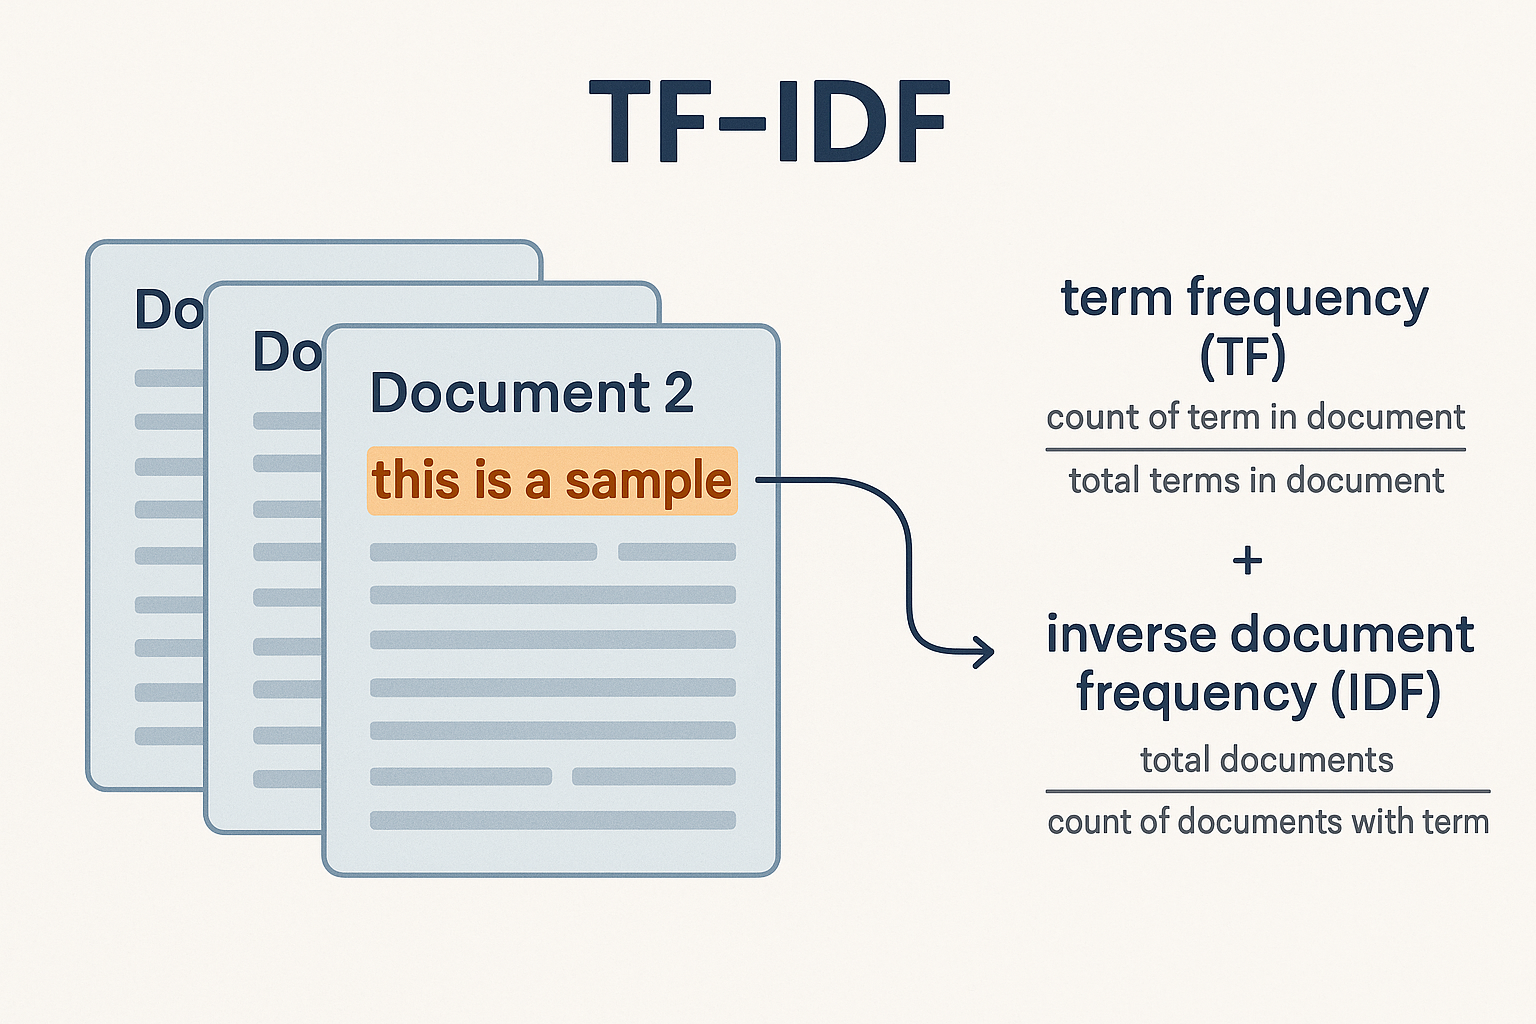

More details: [TDM and TF-IDF](https://srdas.github.io/NLPBook/Term_Doc_Matrix.html)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

tfidf = TfidfVectorizer()
# tfidf = CountVectorizer()

# Join the tokens back into strings
sentences_as_strings = [" ".join(tokens) for tokens in filtered_sentences.values()]

tfs = tfidf.fit_transform(sentences_as_strings)
tfs

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4607 stored elements and shape (1285, 1369)>

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity matrix
similarity_matrix_tfidf = cosine_similarity(tfs)

# Compute similarity between 2 sentences as an example (using indices from the original sentences list)
i = 9
j = 10
s1_tfidf = similarity_matrix_tfidf[i]
s2_tfidf = similarity_matrix_tfidf[j]

# The similarity between sentence i and sentence j is directly available in the matrix
similarity_score_example = similarity_matrix_tfidf[i, j]

# Get the original sentences for display (using the list of strings created for TF-IDF)
sentences_list = [str(value) for value in sent_combined_named.values() if pd.notna(value)]

print(f"Similarity between '{sentences_list[i]}' and '{sentences_list[j]}': {similarity_score_example:.4f}")

Similarity between 'Debt Relief  ' and 'Debt Restructuring  ': 0.3662


In [30]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity matrix
similarity_matrix_tfidf = cosine_similarity(tfs)

print("Cosine similarity matrix computed using TF-IDF.")

Cosine similarity matrix computed using TF-IDF.


In [31]:
# Create a pandas DataFrame from the similarity matrix
# Use valid_keys as both the index and columns to ensure proper topic ID mapping
#valid_keys = [key for key, value in sent_combined_named.items() if pd.notna(value)]
similarity_df_tfidf = pd.DataFrame(similarity_matrix_tfidf, index=filtered_sentences, columns=filtered_sentences)

# Initialize a list to store the results
top_similarities_table_data_tfidf = []

# Iterate through each IMF topic
imf_topic_ids = set(imf_tax['imfTopicID'])
wb_topic_ids = set(wb_tax['wbTopicID'])

for imf_topic_id in imf_topic_ids:
    # Check if the IMF topic is in the similarity_df_tfidf index
    if imf_topic_id in similarity_df_tfidf.index:
        # Get the similarity scores for this IMF topic with all other topics
        imf_similarities = similarity_df_tfidf.loc[imf_topic_id]

        # Filter for similarities with WB topics only
        wb_similarities = imf_similarities[imf_similarities.index.isin(wb_topic_ids)]

        # Sort the WB similarities in descending order and get the top 5
        top_5_wb_similarities = wb_similarities.sort_values(ascending=False).head(5)

        # Add the top 5 similar WB topics and their scores to the results list
        for wb_topic_id, score in top_5_wb_similarities.items():
            top_similarities_table_data_tfidf.append({
                'IMF Topic ID': imf_topic_id,
                'IMF Label': filtered_sentences[imf_topic_id], # use sent_combined_named[imf_topic_id] to display full sentence
                'Top WB Topic ID': wb_topic_id,
                'Top WB Label': filtered_sentences[wb_topic_id], # use sent_combined_named[wb_topic_id] to display full sentence
                'Similarity Score': score
            })

# Create a pandas DataFrame from the results
top_similarities_df_tfidf = pd.DataFrame(top_similarities_table_data_tfidf)

# Display the DataFrame
print("Top 5 most similar WB topics for each IMF topic based on TF-IDF similarity:")
display(top_similarities_df_tfidf)

Top 5 most similar WB topics for each IMF topic based on TF-IDF similarity:


,IMF Topic ID,IMF Label,Top WB Topic ID,Top WB Label,Similarity Score
0,E52_IR,"[countri, extern, asset, currenc, gold]",WB2065,"[extern, audit]",0.326898
1,E52_IR,"[countri, extern, asset, currenc, gold]",WB877,"[asset, manag]",0.298764
2,E52_IR,"[countri, extern, asset, currenc, gold]",WB1610,"[asset, transfer]",0.250977
3,E52_IR,"[countri, extern, asset, currenc, gold]",WB2586,"[landlock, countri]",0.222457
4,E52_IR,"[countri, extern, asset, currenc, gold]",WB2072,"[stolen, asset]",0.210767
...,...,...,...,...,...
575,F31,"[exchang, rate, reserv, capit, flow, trade]",WB1127,"[reserv, rate]",0.590755
576,F31,"[exchang, rate, reserv, capit, flow, trade]",WB1124,"[exchang, rate, polici]",0.521668
577,F31,"[exchang, rate, reserv, capit, flow, trade]",WB2459,"[illicit, financi, flow, capit]",0.436768
578,F31,"[exchang, rate, reserv, capit, flow, trade]",WB444,"[monetari, polici, exchang, rate]",0.426243


### word2vec embeddings
What are embeddings?: https://srdas.github.io/NLPBook/Word2Vec.html

#### Prepare data

Flatten the list of tokenized words from all sentences into a single list for training the Word2Vec model.


In [32]:
all_words = []
for tokens in filtered_sentences.values():
    all_words.extend(tokens)

# Display the first few words to verify
print(all_words[:20])

['femal', 'youth', 'entrepreneurship', 'gender', 'women', 'busi', 'inclus', 'growth', 'innov', 'inflat', 'monetari', 'polici', 'exchang', 'rate', 'intern', 'remitt', 'fiscal', 'polici', 'sustain', 'rule']


#### Train word2vec model

Train a Word2Vec model on the prepared text data.


In [33]:
# Make sure to install gensim
!pip install gensim
from gensim.models import Word2Vec

# Instantiate the Word2Vec model
# vector_size: dimensionality of the word vectors
# window: maximum distance between the current and predicted word within a sentence
# min_count: ignores all words with total frequency lower than this
word2vec_model = Word2Vec(sentences=list(filtered_sentences.values()), vector_size=100, window=5, min_count=1, workers=4)

# Train the model
# The sentences parameter is a list of lists of words, which is the format of filtered_sentences.values()
word2vec_model.train(list(filtered_sentences.values()), total_examples=word2vec_model.corpus_count, epochs=10)

print("Word2Vec model trained successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.2 MB/s eta 0:00:00


Word2Vec model trained successfully.


#### Generate sentence embeddings

For each topic sentence, generate an embedding by averaging the Word2Vec embeddings of its words.


In [34]:
sent_word2vec_embeddings = {}
vector_size = word2vec_model.vector_size

for topic_id, tokens in filtered_sentences.items():
    valid_embeddings = [word2vec_model.wv[word] for word in tokens if word in word2vec_model.wv]

    if valid_embeddings:
        # Calculate the mean of word embeddings
        sentence_embedding = np.mean(valid_embeddings, axis=0)
    else:
        # Assign a zero vector if no words are in the vocabulary
        sentence_embedding = np.zeros(vector_size)

    sent_word2vec_embeddings[topic_id] = sentence_embedding

# Convert the dictionary to a list of embeddings, maintaining the order of valid_keys
# valid_keys was created in a previous step to ensure order consistent with similarity_df
valid_keys = [key for key, value in sent_combined_named.items() if pd.notna(value)]
vec_word2vec_combined = np.array([sent_word2vec_embeddings[key] for key in valid_keys])

print("Sentence embeddings generated using Word2Vec.")
print(f"Shape of combined Word2Vec embeddings: {vec_word2vec_combined.shape}")

Sentence embeddings generated using Word2Vec.
Shape of combined Word2Vec embeddings: (1285, 100)


#### Calculate similarity matrix

Compute the cosine similarity between the Word2Vec sentence embeddings.


In [35]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix_word2vec = cosine_similarity(vec_word2vec_combined)
print("Cosine similarity matrix computed using Word2Vec embeddings.")

Cosine similarity matrix computed using Word2Vec embeddings.


#### Identify top similarities

Find the top similar pairs of WB and IMF topics based on the Word2Vec similarity scores and display them in a table, similar to the previous analysis. Create a pandas DataFrame from the Word2Vec similarity matrix and identify the top similar WB-IMF topic pairs, excluding within-group similarities, and store them in a list of dictionaries to create a DataFrame for display.


In [36]:
# Create a pandas DataFrame from the similarity matrix
# Use valid_keys as both the index and columns to ensure proper topic ID mapping and to display the full sentence instead of the processed ones (filtered_sentences)
# valid_keys = [key for key, value in sent_combined_named.items() if pd.notna(value)]
# similarity_df_word2vec = pd.DataFrame(similarity_matrix_word2vec, index=valid_keys, columns=valid_keys)
similarity_df_word2vec = pd.DataFrame(similarity_matrix_word2vec, index=filtered_sentences, columns=filtered_sentences)

# Initialize a list to store the results
top_similarities_table_data_word2vec = []

# Iterate through each IMF topic
imf_topic_ids = set(imf_tax['imfTopicID'])
wb_topic_ids = set(wb_tax['wbTopicID'])

for imf_topic_id in imf_topic_ids:
    # Check if the IMF topic is in the similarity_df_word2vec index
    if imf_topic_id in similarity_df_word2vec.index:
        # Get the similarity scores for this IMF topic with all other topics
        imf_similarities = similarity_df_word2vec.loc[imf_topic_id]

        # Filter for similarities with WB topics only
        wb_similarities = imf_similarities[imf_similarities.index.isin(wb_topic_ids)]

        # Sort the WB similarities in descending order and get the top 5
        top_5_wb_similarities = wb_similarities.sort_values(ascending=False).head(5)

        # Add the top 5 similar WB topics and their scores to the results list
        for wb_topic_id, score in top_5_wb_similarities.items():
            top_similarities_table_data_word2vec.append({
                'IMF Topic ID': imf_topic_id,
                'IMF Label': filtered_sentences[imf_topic_id], # use sent_combined_named[imf_topic_id] to display full sentence
                'Top WB Topic ID': wb_topic_id,
                'Top WB Label': filtered_sentences[wb_topic_id], # use sent_combined_named[wb_topic_id] to display full sentence
                'Similarity Score': score
            })

# Create a pandas DataFrame from the results
top_similarities_df_word2vec = pd.DataFrame(top_similarities_table_data_word2vec)

# Display the DataFrame
print("Top 5 most similar WB topics for each IMF topic based on Word2Vec similarity:")
display(top_similarities_df_word2vec)

Top 5 most similar WB topics for each IMF topic based on Word2Vec similarity:


,IMF Topic ID,IMF Label,Top WB Topic ID,Top WB Label,Similarity Score
0,E52_IR,"[countri, extern, asset, currenc, gold]",WB877,"[asset, manag]",0.980748
1,E52_IR,"[countri, extern, asset, currenc, gold]",WB1747,"[product, market, regul, competit, advocaci, a...",0.979932
2,E52_IR,"[countri, extern, asset, currenc, gold]",WB776,"[trade, polici, restrict, market, access]",0.979841
3,E52_IR,"[countri, extern, asset, currenc, gold]",WB855,"[labor, market, employ, growth, improv, market...",0.979433
4,E52_IR,"[countri, extern, asset, currenc, gold]",WB813,"[urban, govern, citi, system, financ, municip,...",0.978833
...,...,...,...,...,...
575,F31,"[exchang, rate, reserv, capit, flow, trade]",WB782,"[servic, trade, competit]",0.985262
576,F31,"[exchang, rate, reserv, capit, flow, trade]",WB1124,"[exchang, rate, polici]",0.984814
577,F31,"[exchang, rate, reserv, capit, flow, trade]",WB724,"[human, resourc, public, sector, employ, civil...",0.984744
578,F31,"[exchang, rate, reserv, capit, flow, trade]",WB1305,"[health, servic, deliveri, system, care, servic]",0.984587


#### Summary

*   Word2Vec model was successfully trained on the combined text data from WB and IMF sentences.
*   Sentence embeddings were generated for each sentence by averaging the Word2Vec embeddings of its constituent words.
*   The cosine similarity matrix was computed between all sentence embeddings.
*   The top 5 most similar pairs of WB and IMF sentences, based on their Word2Vec similarity scores, were identified and presented in a table with their respective IDs, labels, and similarity scores.


### sent2vec embeddings

https://srdas.github.io/NLPBook/Word2Vec.html#using-sent2vec

#### Vectorizing sentences

In [39]:
from scipy import spatial # for cosine distance
from sent2vec.vectorizer import Vectorizer # uses DistilBERT

sent2vec does not handle text processing like lowercasing, tokenization, etc.

https://github.com/epfml/sent2vec?tab=readme-ov-file#sent2vec

In [40]:
sent_combined = [" ".join(value) for value in filtered_sentences.values()] # make sure to remove NAs
vectorizer = Vectorizer()
vec_bert_combined = vectorizer.run(sent_combined)
vec_bert_combined = vectorizer.vectors

Initializing Bert distilbert-base-uncased
Vectorization done on cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


In [41]:
sent_combined = [str(value) for value in sent_combined_named.values() if pd.notna(value)] # make sure to remove NAs
vectorizer = Vectorizer()
vec_bert_combined = vectorizer.run(sent_combined)
vec_bert_combined = vectorizer.vectors

Initializing Bert distilbert-base-uncased
Vectorization done on cuda


In [42]:
# Compute distances between 2 sentences as an example
i = 0
j = 1
s1 = vec_bert_combined[i]
s2 = vec_bert_combined[j]
dist = 1 - spatial.distance.cosine(s1, s2) # Similarity = 1 - Distance
print(list(filtered_sentences.values())[i],"/",list(filtered_sentences.values())[j], dist)

['femal', 'youth', 'entrepreneurship', 'gender', 'women', 'busi'] / ['inclus', 'growth', 'innov'] 0.9072648


#### Calculate similarity matrix

Compute the cosine similarity between all pairs of sentence embeddings in `vec_bert_combined`.


In [43]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(vec_bert_combined)

#### Similarities Data Frame

Store the similarity scores in a pandas DataFrame for easier manipulation and analysis. Create a pandas DataFrame from the similarity matrix and set the index and columns to the topic IDs from the combined named list.


In [44]:
# Get the keys corresponding to the non-NaN values used in sent_combined
valid_keys = [key for key, value in sent_combined_named.items() if pd.notna(value)]

similarity_df = pd.DataFrame(similarity_matrix, index=valid_keys, columns=valid_keys)
display(similarity_df.head())

,WB398,WB400,WB442,WB444,WB355,WB445,WB449,WB450,WB451,WB452,...,G32,G18_NFIS,G15,G11,EFA,C53,FAC,FAC_A,FAC_B,WP
WB398,1.000000,0.907265,0.864112,0.931208,0.905258,0.946245,0.954339,0.955903,0.889763,0.886046,...,0.911749,0.914051,0.917446,0.879964,0.888397,0.872710,0.910686,0.910762,0.919716,0.896240
WB400,0.907265,1.000000,0.987817,0.982283,0.992927,0.950832,0.964124,0.973218,0.989599,0.989284,...,0.985152,0.983230,0.983383,0.987637,0.989212,0.987144,0.984754,0.982830,0.981919,0.986214
WB442,0.864112,0.987817,1.000000,0.968428,0.991557,0.922730,0.938163,0.952551,0.993763,0.995337,...,0.982222,0.978029,0.977879,0.992452,0.992627,0.995311,0.982254,0.978756,0.973039,0.987061
WB444,0.931208,0.982283,0.968428,1.000000,0.983426,0.958194,0.982399,0.985296,0.976029,0.973983,...,0.978991,0.978816,0.982196,0.977236,0.976034,0.966754,0.979993,0.977010,0.977666,0.967515
WB355,0.905258,0.992927,0.991557,0.983426,1.000000,0.947478,0.963667,0.975757,0.993590,0.994598,...,0.989400,0.987307,0.987731,0.990178,0.991355,0.989307,0.989361,0.986791,0.987092,0.989452


#### Identify top similarities

Find the pairs of sentences with the highest similarity scores. Iterate through the similarity matrix to find the pairs of sentences with the highest similarity scores, excluding self-similarities, and store them with their topic IDs in a list of tuples. Then sort the list in descending order based on similarity and select the top 20 pairs.


In [45]:
# Iterate through the similarity_df DataFrame to find the top similar pairs
top_similarities = []
wb_topic_ids = set(wb_tax['wbTopicID'])
imf_topic_ids = set(imf_tax['imfTopicID'])

for i in range(len(similarity_df.index)):
    for j in range(i + 1, len(similarity_df.columns)):
        topic1_id = similarity_df.index[i]
        topic2_id = similarity_df.columns[j]

        # Exclude similarities within the same group (WB-WB or IMF-IMF)
        if (topic1_id in wb_topic_ids and topic2_id in wb_topic_ids) or \
           (topic1_id in imf_topic_ids and topic2_id in imf_topic_ids):
            continue

        similarity_score = similarity_df.iloc[i, j]
        top_similarities.append((similarity_score, (topic1_id, topic2_id)))

# Sort the list of tuples in descending order
top_similarities.sort(key=lambda x: x[0], reverse=True)

# Select the top N pairs (e.g., top 20)
top_n = 20
top_n_similarities = top_similarities[:top_n]

# Display the top N similar pairs
print(f"Top {top_n} most similar topic pairs (excluding within-group similarities):")
for score, (topic1, topic2) in top_n_similarities:
    print(f"{topic1} and {topic2}: {score:.4f}")

Top 20 most similar topic pairs (excluding within-group similarities):
WB376 and E42: 0.9965
WB567 and Q58: 0.9964
WB700 and G28: 0.9961
WB1774 and Q58: 0.9960
WB1245 and G18_SR: 0.9960
WB528 and Q58: 0.9959
WB1098 and G28: 0.9959
WB1774 and C53: 0.9959
WB1245 and G11: 0.9958
WB1098 and G18_SR: 0.9958
WB1846 and Q58: 0.9958
WB2673 and EFA: 0.9958
WB529 and Q58: 0.9958
WB533 and Q58: 0.9958
WB1857 and C53: 0.9958
WB1026 and C53: 0.9958
WB551 and E23_P: 0.9958
WB1852 and Q58: 0.9958
WB137 and Q58: 0.9957
WB1144 and C53: 0.9957


#### Map back to topic ids

Use the original topic IDs (`wbTopicID` and `imfTopicID`) from `sent_combined_named` to identify the specific topics associated with the most similar sentences.


In [46]:
print("\nTop 20 most similar topics (IMF and WB):")
for score, (topic1_id, topic2_id) in top_n_similarities:
    topic1_label = sent_combined_named[topic1_id]
    topic2_label = sent_combined_named[topic2_id]
    print(f"Similarity: {score:.4f}")
    print(f"  Topic 1 ({topic1_id}): {topic1_label}")
    print(f"  Topic 2 ({topic2_id}): {topic2_label}")
    print("-" * 20)


Top 20 most similar topics (IMF and WB):
Similarity: 0.9965
  Topic 1 (WB376): Innovation, Technology and Entrepreneurship  
  Topic 2 (E42): Financial technology innovations.
--------------------
Similarity: 0.9964
  Topic 1 (WB567): Climate Change  
  Topic 2 (Q58): Reducing greenhouse gas emissions.
--------------------
Similarity: 0.9961
  Topic 1 (WB700): Inequality and Shared Prosperity  
  Topic 2 (G28): Simulating adverse economic scenarios.
--------------------
Similarity: 0.9960
  Topic 1 (WB1774): Climate Forecasting  
  Topic 2 (Q58): Reducing greenhouse gas emissions.
--------------------
Similarity: 0.9960
  Topic 1 (WB1245): Financial Vulnerability and Risks  
  Topic 2 (G18_SR): Risk of widespread financial disruption.
--------------------
Similarity: 0.9959
  Topic 1 (WB528): Solar Energy  
  Topic 2 (Q58): Reducing greenhouse gas emissions.
--------------------
Similarity: 0.9959
  Topic 1 (WB1098): Monetary and Financial Stability  
  Topic 2 (G28): Simulating adver

In [47]:
# Show top 5 WB most similar
# Create a list to store the results
top_similarities_table_data = []

# Iterate through each IMF topic
for imf_topic_id in imf_tax['imfTopicID']:
    # Check if the IMF topic is in the similarity_df index (i.e., it had a non-NaN fullLabel)
    if imf_topic_id in similarity_df.index:
        # Get the similarity scores for this IMF topic with all other topics
        imf_similarities = similarity_df.loc[imf_topic_id]

        # Filter for similarities with WB topics only and exclude self-similarity
        wb_similarities = imf_similarities[imf_similarities.index.isin(wb_tax['wbTopicID'])]

        # Sort the WB similarities in descending order and get the top 5
        top_5_wb_similarities = wb_similarities.sort_values(ascending=False).head(5)

        # Add the top 5 similar WB topics and their scores to the results list
        for wb_topic_id, score in top_5_wb_similarities.items():
            top_similarities_table_data.append({
                'IMF Topic ID': imf_topic_id,
                'IMF Label': filtered_sentences[imf_topic_id], # use sent_combined_named[imf_topic_id] to display full sentence
                'Top WB Topic ID': wb_topic_id,
                'Top WB Label': filtered_sentences[wb_topic_id], # use sent_combined_named[wb_topic_id] to display full sentence
                'Similarity Score': score
            })

# Create a pandas DataFrame from the results
top_similarities_df_sent2vec = pd.DataFrame(top_similarities_table_data)

# Display the DataFrame
display(top_similarities_df_sent2vec)

,IMF Topic ID,IMF Label,Top WB Topic ID,Top WB Label,Similarity Score
0,DEM,"[popul, social, labor, market, data]",WB2788,"[labor, market, institut, polici]",0.990699
1,DEM,"[popul, social, labor, market, data]",WB1785,"[environment, polici, institut]",0.990600
2,DEM,"[popul, social, labor, market, data]",WB919,"[gender, human, develop]",0.990568
3,DEM,"[popul, social, labor, market, data]",WB435,"[agricultur, food, secur]",0.990482
4,DEM,"[popul, social, labor, market, data]",WB1722,"[hous, polici, institut]",0.990435
...,...,...,...,...,...
575,WP,"[dataset, research, paper]",WB579,"[climat, chang, mitig]",0.994072
576,WP,"[dataset, research, paper]",WB959,"[climat, chang, law]",0.993648
577,WP,"[dataset, research, paper]",WB2734,"[worker, disabl]",0.993621
578,WP,"[dataset, research, paper]",WB1244,"[disclosur, inform]",0.993463


### Compare results

In [48]:
# Concatenate the dataframes for comparison
comparison_table = pd.concat([
    top_similarities_df_med.assign(Method='MED'),
    top_similarities_df_tfidf.assign(Method='TF-IDF'),
    top_similarities_df_word2vec.assign(Method='Word2Vec'),
    top_similarities_df_sent2vec.assign(Method='sent2vec')
])

# Display the comparison table
display(comparison_table)

,IMF Topic ID,IMF Label,Top WB Topic ID,Top WB Label,Minimum Edit Distance,Method,Similarity Score
0,E52_IR,"[countri, extern, asset, currenc, gold]",WB2025,"[investig, asset, recoveri]",20.0,MED,NaN
1,E52_IR,"[countri, extern, asset, currenc, gold]",WB903,"[develop, transit, orient, tod]",20.0,MED,NaN
2,E52_IR,"[countri, extern, asset, currenc, gold]",WB436,"[forestri, forest, tree, grow]",21.0,MED,NaN
3,E52_IR,"[countri, extern, asset, currenc, gold]",WB2156,"[continuum, care, coc]",21.0,MED,NaN
4,E52_IR,"[countri, extern, asset, currenc, gold]",WB2334,"[univers, servic, fund]",21.0,MED,NaN
...,...,...,...,...,...,...,...
575,WP,"[dataset, research, paper]",WB579,"[climat, chang, mitig]",NaN,sent2vec,0.994072
576,WP,"[dataset, research, paper]",WB959,"[climat, chang, law]",NaN,sent2vec,0.993648
577,WP,"[dataset, research, paper]",WB2734,"[worker, disabl]",NaN,sent2vec,0.993621
578,WP,"[dataset, research, paper]",WB1244,"[disclosur, inform]",NaN,sent2vec,0.993463


In [49]:
# Function to get the top WB match for each IMF topic from a results DataFrame
def get_top_wb_match(results_df, method_name):
    top_matches = {}
    for imf_topic_id in imf_tax['imfTopicID']:
        if imf_topic_id in results_df['IMF Topic ID'].values:
            # Get the top match for this IMF topic (first row after sorting by similarity/distance)
            top_match_row = results_df[results_df['IMF Topic ID'] == imf_topic_id].iloc[0]
            top_matches[imf_topic_id] = {
                'IMF Label': sent_combined_named[imf_topic_id],
                f'Top WB Topic ID ({method_name})': top_match_row['Top WB Topic ID'],
                f'Top WB Label ({method_name})': sent_combined_named[top_match_row['Top WB Topic ID']]
            }
    return pd.DataFrame.from_dict(top_matches, orient='index')

# Get top matches for each method
top_med = get_top_wb_match(top_similarities_df_med, 'MED')
top_tfidf = get_top_wb_match(top_similarities_df_tfidf, 'TF-IDF')
top_word2vec = get_top_wb_match(top_similarities_df_word2vec, 'Word2Vec')
top_sent2vec = get_top_wb_match(top_similarities_df_sent2vec, 'sent2vec')

# Merge the results into a single DataFrame, dropping 'IMF Label' from the right dataframes
comparison_summary = top_med.merge(top_tfidf.drop(columns=['IMF Label']), left_index=True, right_index=True, how='outer')
comparison_summary = comparison_summary.merge(top_word2vec.drop(columns=['IMF Label']), left_index=True, right_index=True, how='outer')
comparison_summary = comparison_summary.merge(top_sent2vec.drop(columns=['IMF Label']), left_index=True, right_index=True, how='outer')


# Reorder columns to have IMF Label first, then pairs of WB Topic ID and Label for each method
cols = ['IMF Label']
method_cols = ['MED', 'TF-IDF', 'Word2Vec', 'sent2vec']
for method in method_cols:
    cols.append(f'Top WB Topic ID ({method})')
    cols.append(f'Top WB Label ({method})')

comparison_summary = comparison_summary[cols]

# Display the summary table
print("Top WB Topic Match for Each IMF Topic Across Different Methods:")
display(comparison_summary)

Top WB Topic Match for Each IMF Topic Across Different Methods:


,IMF Label,Top WB Topic ID (MED),Top WB Label (MED),Top WB Topic ID (TF-IDF),Top WB Label (TF-IDF),Top WB Topic ID (Word2Vec),Top WB Label (Word2Vec),Top WB Topic ID (sent2vec),Top WB Label (sent2vec)
C53,Economic forecasts.,WB1774,Climate Forecasting,WB1774,Climate Forecasting,WB1540,Economics of Education,WB1774,Climate Forecasting
CLM,"Environmental conditions, climate change.",WB1785,Environmental Policies and Institutions,WB567,Climate Change,WB567,Climate Change,WB567,Climate Change
DEM,"Population, social, and labor market data.",WB662,Social Media,WB697,Social Protection and Labor,WB697,Social Protection and Labor,WB2788,Labor Market Institutions and Policies
E01,Total income earned by residents.,WB2668,Income Inequality,WB2741,Self-Employment Income,WB2021,Income and Asset Disclosure Financial Disclosu...,WB700,Inequality and Shared Prosperity
E10,Measures economic activity; framework for the ...,WB730,Management Information Systems Performance Mon...,WB2583,Performance Measurement,WB730,Management Information Systems Performance Mon...,WB2060,Budget Preparation and Management Techniques S...
...,...,...,...,...,...,...,...,...,...
Q56,The natural environment and human interaction.,WB600,Natural Resources Management,WB566,Environment and Natural Resources,WB566,Environment and Natural Resources,WB1020,Law of the Sea
Q57,Risks related to climate change.,WB747,Social Resilience and Climate Change Climate R...,WB567,Climate Change,WB567,Climate Change,WB1785,Environmental Policies and Institutions
Q58,Reducing greenhouse gas emissions.,WB1518,Education Reform,WB1757,Reduced Emissions from Deforestation and Degra...,WB540,Governance for Oil and Gas,WB567,Climate Change
R30,Prices of real estate properties.,WB680,Personal Data Protection,WB964,Property and Land Law Real Estate Law Real Est...,WB964,Property and Land Law Real Estate Law Real Est...,WB1098,Monetary and Financial Stability


### Try with AI

*Sample prompt:*

Score the semantic similarity of the sent_wb_named sentences against sent_imf_named sentences on a scale of 0 to 5, where 5 is identical meaning and 0 is completely unrelated. For each sent_imf_named sentence, return the top scoring sentence in sent_wb_named

**Semantic Similarity Scoring with Sentence Embeddings**

We will use a pre-trained sentence embedding model to generate embeddings for the IMF and WB sentences and then compute cosine similarity between them. We'll then scale these similarity scores to a 0-5 range.

In [50]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load a pre-trained sentence transformer model
# 'all-MiniLM-L6-v2' is a good general-purpose model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for IMF and WB sentences
# Ensure we are using the original sentences before text processing
imf_sentences = list(sent_imf_named.values())
wb_sentences = list(sent_wb_named.values())

imf_embeddings = model.encode(imf_sentences)
wb_embeddings = model.encode(wb_sentences)

print("Sentence embeddings generated.")
print(f"Shape of IMF embeddings: {imf_embeddings.shape}")
print(f"Shape of WB embeddings: {wb_embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence embeddings generated.
Shape of IMF embeddings: (116, 384)
Shape of WB embeddings: (1169, 384)


**Calculate and Scale Similarity Scores**

In [51]:
# Calculate cosine similarity between IMF and WB embeddings
similarity_matrix_semantic = cosine_similarity(imf_embeddings, wb_embeddings)

# Scale the similarity scores from [0, 1] to [0, 5]
# The original cosine similarity is in the range [-1, 1].
# We will first scale it to [0, 1] using (score + 1) / 2, and then to [0, 5] by multiplying by 5.
# However, sentence-transformer models usually produce scores in [0, 1] range for cosine similarity of relevant sentences, so we'll directly scale from [0, 1] to [0, 5].
scaled_similarity_matrix = similarity_matrix_semantic * 5

print("Semantic similarity matrix calculated and scaled to 0-5.")
print(f"Shape of scaled similarity matrix: {scaled_similarity_matrix.shape}")

Semantic similarity matrix calculated and scaled to 0-5.
Shape of scaled similarity matrix: (116, 1169)


**Identify Top Matches**

In [52]:
# Create a list to store the top matches
top_semantic_matches = []

# Get the lists of IMF and WB topic IDs to use as labels
imf_topic_ids_list = list(sent_imf_named.keys())
wb_topic_ids_list = list(sent_wb_named.keys())

# Iterate through each IMF sentence's similarity scores
for i, imf_topic_id in enumerate(imf_topic_ids_list):
    # Get the similarity scores for the current IMF sentence against all WB sentences
    wb_scores = scaled_similarity_matrix[i, :]

    # Find the index of the highest similarity score
    top_match_index = np.argmax(wb_scores)

    # Get the corresponding WB topic ID, label, and similarity score
    top_wb_topic_id = wb_topic_ids_list[top_match_index]
    top_wb_label = sent_wb_named[top_wb_topic_id]
    top_score = wb_scores[top_match_index]

    # Append the results to the list
    top_semantic_matches.append({
        'IMF Topic ID': imf_topic_id,
        'IMF Label': sent_imf_named[imf_topic_id],
        'Top WB Topic ID (Semantic)': top_wb_topic_id,
        'Top WB Label (Semantic)': top_wb_label,
        'Semantic Similarity Score (0-5)': top_score
    })

# Create a pandas DataFrame from the results
top_semantic_matches_df = pd.DataFrame(top_semantic_matches)

# Display the DataFrame
print("Top WB Topic Match for Each IMF Topic Based on Semantic Similarity (0-5 scale):")
display(top_semantic_matches_df)

Top WB Topic Match for Each IMF Topic Based on Semantic Similarity (0-5 scale):


,IMF Topic ID,IMF Label,Top WB Topic ID (Semantic),Top WB Label (Semantic),Semantic Similarity Score (0-5)
0,DEM,"Population, social, and labor market data.",WB2763,Census Data,3.191916
1,J20,"Employment, unemployment, labor force particip...",WB2746,Labor Participation,3.148484
2,J21,Employed and unemployed people willing to work.,WB2748,Employment,3.140537
3,J64,People actively seeking employment but unable ...,WB2748,Employment,2.466934
4,E24,"Number of employed people (jobs, industries).",WB2895,Employment Rate,2.924247
...,...,...,...,...,...
111,C53,Economic forecasts.,WB1774,Climate Forecasting,3.031866
112,FAC,IMF's financial accounts.,WB1748,Debt Funds,2.704825
113,FAC_A,IMF's financial operations.,WB2196,Financial Intermediaries,2.879719
114,FAC_B,IMF reports on member countries' policies.,WB312,International Financial Standards,2.555829


## Recap and discussion

- Text handling concepts and fundamentals
- From text to numbers: from counting words to embeddings (applying pre-trained models)
- Measures of similarity: from comparing characters to cosine similarities
- Insights on results: problem-based model selection


<h3> <b>❓ What method would you say works best and why?
</b>

<h3> <b>❓ Can you think of other ways to solve this problem?
</b>